In [ ]:
# # Write code to put the detuning mult in the config 
# # So object looks like:
# # {
# #     "config": {
# #         "detuning_mult": detuning_mult,
# #         "input_pickle_file": input_pickle_file,
# #     },
# # }

# from pathlib import Path
# import pickle
# import sys
# from VisualizeVF import VisualizeVF
# sys.path.append('..')
# from FEMSystem import FEMSystem
# from RabiLondonSystem import RabiLondonSystem
# from Units2D import Units2D
# import numpy as np

# # import pickled object
# class _CompatUnpickler(pickle.Unpickler):
#     def find_class(self, module, name):
#         # Older checkpoints store RabiLondon2D as __main__.RabiLondon2D.
#         # Remap to the current implementation class.
#         if module == "__main__" and name == "RabiLondon2D":
#             return RabiLondonSystem
#         return super().find_class(module, name)

# def convert_nums_to_strings(nums):
#     return ["0" if v == 0 else f"{v:.12g}" for v in nums]

# def add_config_to_pickle(filepath, detuning_mult):
#     """Overwrite pickle at filepath after moving input_pickle_file into config."""
#     file_path = Path(filepath)

#     with file_path.open("rb") as f:
#         obj = pickle.load(f)

#     if not isinstance(obj, dict):
#         raise TypeError(f"Expected pickled object to be dict, got {type(obj).__name__}")

#     if "input_pickle_file" not in obj:
#         raise KeyError("Expected key 'input_pickle_file' in pickled object")

#     input_pickle_file = obj.pop("input_pickle_file")

#     existing_config = obj.get("config")
#     if existing_config is None:
#         existing_config = {}
#     elif not isinstance(existing_config, dict):
#         raise TypeError("Existing 'config' field must be a dict if present")

#     existing_config["detuning_mult"] = detuning_mult
#     existing_config["input_pickle_file"] = input_pickle_file
#     obj["config"] = existing_config

#     with file_path.open("wb") as f:
#         pickle.dump(obj, f)


# # One time fix of pickle schema. NEVER RUN THIS AGAIN.

# # max_detuning_mult = 1e-8
# # steps = np.linspace(-max_detuning_mult, max_detuning_mult, 11)
# # numstrings = convert_nums_to_strings(steps)

# # from pathlib import Path

# # REPO_ROOT = Path.cwd().parent  # if cwd is .../cqednumerics/RabiLondon
# # base = REPO_ROOT / "RabiLondon" / "allplots" / "rabichevron1"

# # for numstring in numstrings:
# #     pkl_path = base / f"sweep_detuning_{numstring}.pkl"
# #     # add_config_to_pickle(pkl_path, float(numstring))
# #     file_path = Path(pkl_path)
# #     with file_path.open("rb") as f:
# #         obj = pickle.load(f) 
# #         print(f"--------Detuning: {numstring}-----------")
# #         print(obj["config"])
# #         print("\n\n")

# Generate Rabi-Chevron Plot from Folder of Rabi-London runs

In [28]:
from pathlib import Path
import pickle
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem
from RabiLondonSystem import RabiLondonSystem
from Units2D import Units2D
import numpy as np

# import pickled object
class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        # Older checkpoints store RabiLondon2D as __main__.RabiLondon2D.
        # Remap to the current implementation class.
        if module == "__main__" and name == "RabiLondon2D":
            return RabiLondonSystem
        return super().find_class(module, name)

def convert_nums_to_strings(nums):
    return ["0" if v == 0 else f"{v:.12g}" for v in nums]

def generate_rabi_oscillations(filepath):

    # Step 1: Load Pickle
    with open(filepath, 'rb') as f:
        pickle_obj = _CompatUnpickler(f).load()
        rabilondon = pickle_obj["rabilondon"]
        A_sol = pickle_obj["A_sol"]
        basis_edge = pickle_obj["basis_edge"]
        source_obj = pickle_obj["source_obj"]
        omega_d_rad_s = pickle_obj["omega_d_rad_s"]
        c_bar = pickle_obj["c_bar"]
        hamiltonian_time_data = pickle_obj["hamiltonian_time_data"]
        kappa = pickle_obj["kappa"]
        config = pickle_obj["config"]
        detuning_mult = config["detuning_mult"]
        if "xi" in pickle_obj:
            xi = pickle_obj["xi"]
        else:
            xi = .39e-10 * 1

    units2d = Units2D(xi,kappa) # Again, for energy conversion, 2D and 3D are the same
    omega_q_nondim = rabilondon.omega_q
    omega_d_nondim = units2d.convert_rad_s_to_energy(omega_d_rad_s,xi)
    
    # Step 2: Decompose Matrices
    A1_mat, A2_mat = hamiltonian_time_data["A1_mat"], hamiltonian_time_data["A2_mat"]
    A1_mat_TLS, A2_mat_TLS= rabilondon.TLS_matrix(A1_mat), rabilondon.TLS_matrix(A2_mat)
    A1_mat_TLS_decomposed, A2_mat_TLS_decomposed = rabilondon.pauli_decompose(A1_mat_TLS), rabilondon.pauli_decompose(A2_mat_TLS)
    A1_TLS_x, A1_TLS_y = A1_mat_TLS_decomposed[1], A1_mat_TLS_decomposed[2]

    # Step 3: Solve for Rabi Magnitude and Frequency
    detuning = omega_d_nondim - omega_q_nondim
    #print(f"Self consistency check: detuning absolute = {detuning} | should be: {omega_q_nondim * detuning_mult}")
    print(f"A1_TLS_x: {A1_TLS_x} | A1_TLS_y: {A1_TLS_y} | detuning: {detuning}")

    rabi_magnitude = (np.abs(A1_TLS_x)**2 + np.abs(A1_TLS_y)**2) / (np.abs(A1_TLS_x)**2 + np.abs(A1_TLS_y)**2 + detuning**2)
    rabi_freq_nondim = np.sqrt(np.abs(A1_TLS_x)**2 + np.abs(A1_TLS_y)**2 + detuning**2)
    rabi_freq_rad_s = units2d.convert_energy_to_rad_s(rabi_freq_nondim,xi)
    rabi_period = float(2*np.pi/rabi_freq_rad_s)

    print(f"Rabi Frequency (in nondim units): {rabi_freq_nondim} | (in rad/s):{rabi_freq_rad_s} or {(rabi_freq_rad_s/(2*np.pi*1e9))} GHz")
    print(f"Rabi Magnitude: {rabi_magnitude} \n\n")

    return rabi_magnitude, rabi_freq_rad_s


# Step 1: Get the strings
max_detuning_mult = 1e-8
steps = np.linspace(-max_detuning_mult, max_detuning_mult, 11)
numstrings = convert_nums_to_strings(steps)

# Step 2: get all Rabi frequencies and magnitudes
rabi_freqs, rabi_magnitudes = [], []

REPO_ROOT = Path.cwd().parent  # if cwd is .../cqednumerics/RabiLondon
base = REPO_ROOT / "RabiLondon" / "allplots" / "rabichevron1"
for numstring in numstrings:
    print(f"***** Detuning: {numstring} | calculating Rabi data *****")
    filepath = base / f"sweep_detuning_{numstring}.pkl"
    rabi_magnitude, rabi_freq_rad_s = generate_rabi_oscillations(filepath)
    rabi_freqs.append(rabi_freq_rad_s)
    rabi_magnitudes.append(rabi_magnitude)

***** Detuning: -1e-08 | calculating Rabi data *****
Effective mass: 4.509837029339474e-34 kg | 0.00024779324337030075 times (2m_e)
A1_TLS_x: 0j | A1_TLS_y: (-6.748468006634312e-09+0j) | detuning: -1.2487301859209765e-08
Rabi Frequency (in nondim units): 1.4194172371761664e-08 | (in rad/s):272776014397.834 or 43.4136510483213 GHz
Rabi Magnitude: 0.22604257595304825 


***** Detuning: -8e-09 | calculating Rabi data *****
Effective mass: 4.509837029339474e-34 kg | 0.00024779324337030075 times (2m_e)
A1_TLS_x: 0j | A1_TLS_y: (-6.750273229272352e-09+0j) | detuning: -9.98984139854997e-09
Rabi Frequency (in nondim units): 1.2056662813422488e-08 | (in rad/s):231698498725.20514 or 36.875961379087606 GHz
Rabi Magnitude: 0.3134645678607815 


***** Detuning: -6e-09 | calculating Rabi data *****
Effective mass: 4.509837029339474e-34 kg | 0.00024779324337030075 times (2m_e)
A1_TLS_x: 0j | A1_TLS_y: (-6.751629921808444e-09+0j) | detuning: -7.49238115993478e-09
Rabi Frequency (in nondim units): 1.00

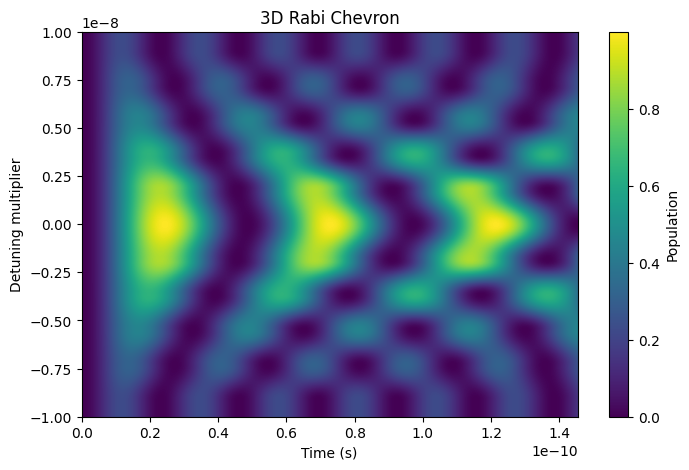

In [26]:
# Step 3: make chevron plot
import matplotlib.pyplot as plt

rabi_magnitudes = np.real(np.asarray(rabi_magnitudes))
rabi_freqs = np.real(np.asarray(rabi_freqs))
detuning_axis = np.real(steps)

max_rabi_period = np.max(2 * np.pi / rabi_freqs)
t_heatmap = np.linspace(0, 3 * max_rabi_period, 500)

population_map = np.array([
    mag * (1 - np.cos(freq * t_heatmap)) / 2
    for mag, freq in zip(rabi_magnitudes, rabi_freqs)
])

plt.figure(figsize=(8, 5))
plt.imshow(
    population_map,
    aspect="auto",
    origin="lower",
    extent=[t_heatmap[0], t_heatmap[-1], detuning_axis[0], detuning_axis[-1]],
    cmap="viridis",
)
plt.colorbar(label="Population")
plt.xlabel("Time (s)")
plt.ylabel("Detuning multiplier")
plt.title("3D Rabi Chevron")
plt.show()